# Unità 6 — E91 con Eve: attacco intercept-resend

In questo notebook introduciamo Eve nel protocollo E91. A differenza di BB84, Eve non intercetta un qubit preparato direttamente da Alice, ma il qubit entangled destinato a Bob. Misurando quel qubit, Eve rompe l'entanglement e poi reinvia a Bob un nuovo qubit preparato secondo la base e il bit ottenuti dalla sua misura.

## Setup e import

In [27]:
from pathlib import Path
import sys

current_path = Path.cwd()

if (current_path / "src" / "e91.py").exists():
    project_root = current_path
elif (current_path.parent / "src" / "e91.py").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("Non trovo la cartella src del progetto.")

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

In [28]:
import importlib
import pandas as pd

import e91

importlib.reload(e91)

from e91 import (
    choose_eve_basis,
    run_e91_round,
    run_e91_protocol,
    run_e91_round_with_eve,
    run_e91_protocol_with_eve,
    run_e91_protocol_with_classical_source,
    sift_keys,
    compute_qber,
    run_chsh_experiment,
    run_chsh_experiment_with_eve,
    run_chsh_experiment_with_classical_source,
)
from metrics import (
    QBER_THRESHOLD_BB84,
    CHSH_CLASSICAL_LIMIT,
    CHSH_TSIRELSON_BOUND,
    bb84_asymptotic_key_rate,
    compute_chsh_gap,
    compute_chsh_strength,
    summarize_chsh_result,
)


## Richiamo del caso ideale

Nel notebook E91 ideale, Alice e Bob misurano qubit appartenenti a una coppia entangled. Quando scelgono la stessa base, i risultati sono correlati e il QBER è nullo in assenza di rumore e attacchi.

In [29]:
results_no_eve = run_e91_protocol_with_eve(
    n_rounds=50,
    intercept_probability=0.0,
    seed=123,
)

alice_key_no_eve, bob_key_no_eve = sift_keys(results_no_eve)
qber_no_eve = compute_qber(alice_key_no_eve, bob_key_no_eve)

print("Lunghezza della chiave sifted senza Eve:", len(alice_key_no_eve))
print("QBER senza Eve:", qber_no_eve)

Lunghezza della chiave sifted senza Eve: 22
QBER senza Eve: 0.0


## Scelta della base di Eve

Eve non conosce le basi di misura usate da Alice e Bob. Per questo sceglie casualmente una base tra `Z` e `X`.

In [30]:
eve_basis = choose_eve_basis(seed=1)
print("Base scelta da Eve:", eve_basis)

Base scelta da Eve: Z


## Singolo round E91 con Eve

Nel singolo round, la sorgente prepara una coppia entangled. Eve intercetta il qubit destinato a Bob, lo misura nella propria base e reinvia a Bob un nuovo qubit coerente con il bit e la base ottenuti. Questo rompe l'entanglement originario tra Alice e Bob.

In [31]:
round_with_eve = run_e91_round_with_eve(
    alice_basis="Z",
    bob_basis="Z",
    intercept_probability=1.0,
    seed=10,
)

print(round_with_eve)

{'alice_basis': 'Z', 'bob_basis': 'Z', 'alice_bit': 1, 'bob_bit': 0, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 1}


## Protocollo multi-round con Eve

Ripetiamo il protocollo per più round. Per ogni round salviamo basi, bit misurati, informazione sul fatto che Eve abbia intercettato, base di Eve e bit di Eve.

In [32]:
results_with_eve = run_e91_protocol_with_eve(
    n_rounds=50,
    intercept_probability=1.0,
    seed=123,
)

for i in range(5):
    print(results_with_eve[i])

{'round': 1, 'alice_basis': 'Z', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 0, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 0}
{'round': 2, 'alice_basis': 'X', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 1, 'keep': True, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 1}
{'round': 3, 'alice_basis': 'X', 'bob_basis': 'X', 'alice_bit': 0, 'bob_bit': 0, 'keep': True, 'eve_intercepted': True, 'eve_basis': 'Z', 'eve_bit': 0}
{'round': 4, 'alice_basis': 'Z', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 0, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 0}
{'round': 5, 'alice_basis': 'X', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 1, 'keep': True, 'eve_intercepted': True, 'eve_basis': 'Z', 'eve_bit': 0}


## Sifting con Eve

Anche in E91 Alice e Bob mantengono solo i round in cui hanno scelto la stessa base, in modo da costruire una chiave sifted.

In [33]:
alice_key_with_eve, bob_key_with_eve = sift_keys(results_with_eve)

print("Chiave di Alice con Eve:", alice_key_with_eve)
print("Chiave di Bob con Eve:", bob_key_with_eve)
print("Lunghezza della chiave sifted con Eve:", len(alice_key_with_eve))

Chiave di Alice con Eve: [1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1]
Chiave di Bob con Eve: [1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0]
Lunghezza della chiave sifted con Eve: 22


## QBER con Eve

Il QBER misura la frazione di errori tra chiave di Alice e chiave di Bob dopo il sifting. Nel caso E91 con intercettazione, ci si aspetta che il QBER aumenti perché Eve rompe l'entanglement e Bob misura uno stato ricostruito da Eve.

In [34]:
qber_with_eve = compute_qber(alice_key_with_eve, bob_key_with_eve)
print("QBER con Eve:", qber_with_eve)

QBER con Eve: 0.22727272727272727


## Confronto essenziale

Confrontiamo il caso senza Eve e il caso con Eve sempre attiva.

In [35]:
print("QBER senza Eve:", qber_no_eve)
print("QBER con Eve:", qber_with_eve)

if qber_with_eve > qber_no_eve:
    print("L'intercettazione di Eve ha aumentato il QBER in questa simulazione.")
else:
    print("In questa simulazione il QBER non è aumentato. Con pochi round possono esserci fluttuazioni statistiche.")

QBER senza Eve: 0.0
QBER con Eve: 0.22727272727272727
L'intercettazione di Eve ha aumentato il QBER in questa simulazione.


## Rappresentazione dei primi risultati

La simulazione restituisce una lista di dizionari coerente con quella già usata nel protocollo BB84 con Eve.

In [36]:
for i in range(10):
    print(results_with_eve[i])

{'round': 1, 'alice_basis': 'Z', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 0, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 0}
{'round': 2, 'alice_basis': 'X', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 1, 'keep': True, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 1}
{'round': 3, 'alice_basis': 'X', 'bob_basis': 'X', 'alice_bit': 0, 'bob_bit': 0, 'keep': True, 'eve_intercepted': True, 'eve_basis': 'Z', 'eve_bit': 0}
{'round': 4, 'alice_basis': 'Z', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 0, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 0}
{'round': 5, 'alice_basis': 'X', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 1, 'keep': True, 'eve_intercepted': True, 'eve_basis': 'Z', 'eve_bit': 0}
{'round': 6, 'alice_basis': 'Z', 'bob_basis': 'X', 'alice_bit': 1, 'bob_bit': 1, 'keep': False, 'eve_intercepted': True, 'eve_basis': 'X', 'eve_bit': 1}
{'round': 7, 'alice_basis': 'Z', 'bob_basis': 'Z', 'alice_bit': 0, 'bob_bit': 0, 'kee

## Commento intermedio

Nel caso ideale il QBER è nullo. Quando Eve intercetta il qubit destinato a Bob, misura una parte della coppia entangled. Questa misura distrugge l'entanglement originario e Bob riceve un qubit ricostruito da Eve. Di conseguenza, le correlazioni tra Alice e Bob vengono degradate e il QBER può aumentare.

## QBER al variare della probabilità di intercettazione

Ora ripetiamo la simulazione per diversi valori di `intercept_probability`, come già fatto per BB84. Questo permette di confrontare quanto il protocollo E91 sia sensibile all'attacco intercept-resend.

In [37]:
interception_probabilities = [0.0, 0.25, 0.5, 0.75, 1.0]
n_rounds = 1000
qber_results = []

for i in range(len(interception_probabilities)):
    probability = interception_probabilities[i]

    results = run_e91_protocol_with_eve(
        n_rounds=n_rounds,
        intercept_probability=probability,
        seed=100 + i,
    )

    alice_key, bob_key = sift_keys(results)
    qber = compute_qber(alice_key, bob_key)

    result = {
        "intercept_probability": probability,
        "n_rounds": n_rounds,
        "sifted_key_length": len(alice_key),
        "qber": qber,
    }

    qber_results.append(result)

    print("Probabilità di intercettazione:", probability)
    print("Lunghezza della chiave sifted:", len(alice_key))
    print("QBER ottenuto:", qber)
    print()

Probabilità di intercettazione: 0.0
Lunghezza della chiave sifted: 495
QBER ottenuto: 0.0

Probabilità di intercettazione: 0.25
Lunghezza della chiave sifted: 492
QBER ottenuto: 0.05894308943089431

Probabilità di intercettazione: 0.5
Lunghezza della chiave sifted: 493
QBER ottenuto: 0.13387423935091278

Probabilità di intercettazione: 0.75
Lunghezza della chiave sifted: 538
QBER ottenuto: 0.21189591078066913

Probabilità di intercettazione: 1.0
Lunghezza della chiave sifted: 500
QBER ottenuto: 0.254



## Tabella risultati

La tabella raccoglie il QBER ottenuto al variare della probabilità di intercettazione.

In [38]:
qber_df = pd.DataFrame(qber_results)
qber_df

,intercept_probability,n_rounds,sifted_key_length,qber
0,0.00,1000,495,0.000000
1,0.25,1000,492,0.058943
2,0.50,1000,493,0.133874
3,0.75,1000,538,0.211896
4,1.00,1000,500,0.254000


## Commento alla tabella

Il QBER tende ad aumentare quando aumenta la probabilità di intercettazione. Nel protocollo E91 l'effetto dell'attacco è interpretabile come perdita delle correlazioni entangled tra Alice e Bob. Eventuali fluttuazioni sono dovute al numero finito di round e alla natura statistica della simulazione.

## Salvataggio e grafico dei risultati

Salviamo la tabella e produciamo un grafico, mantenendo separata la rappresentazione dalla logica del protocollo.

In [39]:
from pathlib import Path

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Cartelle dei risultati pronte.")

Cartelle dei risultati pronte.


In [40]:
table_path = tables_dir / "e91_eve_qber_vs_interception.csv"
qber_df.to_csv(table_path, index=False)

print(f"Tabella salvata in: {table_path}")

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_eve_qber_vs_interception.csv


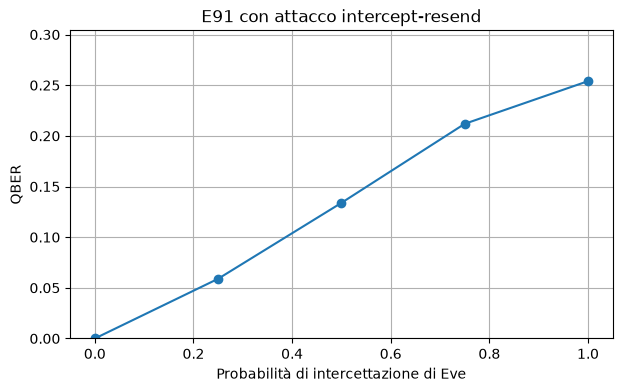

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_eve_qber_vs_interception.png


In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(
    qber_df["intercept_probability"],
    qber_df["qber"],
    marker="o",
)
plt.xlabel("Probabilità di intercettazione di Eve")
plt.ylabel("QBER")
plt.title("E91 con attacco intercept-resend")
plt.grid(True)
plt.ylim(0, max(0.3, qber_df["qber"].max() + 0.05))

figure_path = figures_dir / "e91_eve_qber_vs_interception.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico salvato in: {figure_path}")

## Commento finale

Per `intercept_probability = 0` il QBER resta nullo nel caso ideale. Aumentando la probabilità di intercettazione, il QBER tende ad aumentare. Nel caso E91, l'attacco intercept-resend è particolarmente significativo perché la misura di Eve distrugge l'entanglement tra Alice e Bob. Questa simulazione prepara il confronto finale tra BB84 ed E91 in presenza di Eve. In un'estensione successiva si potrà valutare anche l'effetto dell'attacco sul parametro CHSH.

## Controllo CHSH in presenza di Eve

Nel protocollo E91 il QBER non ? l'unica metrica interessante. Poich? E91 si basa su coppie entangled, Alice e Bob possono anche verificare la presenza di correlazioni non classiche tramite il parametro CHSH S.

Nel caso ideale ci si aspetta |S| > 2, vicino al valore quantistico massimo 2?2. In presenza di Eve, l'attacco intercept-resend rompe l'entanglement e quindi tende a ridurre |S|.

Nel notebook usiamo due riferimenti teorici:

- |S| > 2 indica violazione della disuguaglianza CHSH;
- 2?2 ? il limite quantistico ideale di Tsirelson.

Non introduciamo una soglia CHSH universale di sicurezza. Usiamo invece `chsh_gap` e `chsh_strength` per interpretare quantitativamente quanto la violazione sia forte.


In [42]:
shots_chsh = 2000
seed_chsh = 1

chsh_ideal = run_chsh_experiment(
    shots=shots_chsh,
    seed=seed_chsh,
)

print(chsh_ideal)


{'E_ab': 0.662, 'E_ab_prime': 0.694, 'E_a_prime_b': 0.697, 'E_a_prime_b_prime': -0.7, 'S': 2.753, 'shots': 2000, 'abs_S': 2.753, 'classical_limit': 2.0, 'quantum_limit': np.float64(2.8284271247461903), 'violates_chsh': True, 'chsh_gap': 0.7530000000000001, 'chsh_strength': np.float64(0.9089514062334703)}


Nel caso ideale |S| dovrebbe superare il limite classico 2. Piccole fluttuazioni rispetto a 2?2 sono dovute al numero finito di shots usato nella simulazione.


In [43]:
chsh_eve_full = run_chsh_experiment_with_eve(
    intercept_probability=1.0,
    shots=shots_chsh,
    seed=seed_chsh,
)

print(chsh_eve_full)


{'E_ab': 0.365, 'E_ab_prime': 0.344, 'E_a_prime_b': 0.39, 'E_a_prime_b_prime': -0.338, 'S': 1.437, 'intercept_probability': 1.0, 'shots': 2000, 'abs_S': 1.437, 'classical_limit': 2.0, 'quantum_limit': np.float64(2.8284271247461903), 'violates_chsh': False, 'chsh_gap': -0.563, 'chsh_strength': np.float64(-0.679601117808026)}


Con Eve sempre attiva ci si aspetta una riduzione significativa di |S|, perch? la misura di Eve distrugge l?entanglement tra Alice e Bob.


## CHSH al variare della probabilit? di intercettazione

Ripetiamo il controllo CHSH per diversi valori di `intercept_probability`. Questo permette di osservare la degradazione progressiva delle correlazioni entangled.


In [44]:
chsh_interception_probabilities = [0.0, 0.25, 0.5, 0.75, 1.0]
shots_chsh_sweep = 2000
chsh_results = []

for i in range(len(chsh_interception_probabilities)):
    probability = chsh_interception_probabilities[i]

    result = run_chsh_experiment_with_eve(
        intercept_probability=probability,
        shots=shots_chsh_sweep,
        seed=300 + i,
    )
    chsh_summary = summarize_chsh_result(result)

    chsh_row = {
        "intercept_probability": probability,
        "shots": shots_chsh_sweep,
        "S": chsh_summary["S"],
        "abs_S": chsh_summary["abs_S"],
        "violates_chsh": chsh_summary["violates_chsh"],
        "chsh_gap": chsh_summary["chsh_gap"],
        "chsh_strength": chsh_summary["chsh_strength"],
        "classical_limit": chsh_summary["classical_limit"],
        "quantum_limit": chsh_summary["quantum_limit"],
    }

    chsh_results.append(chsh_row)

    print("Probabilit? di intercettazione:", probability)
    print("|S|:", chsh_summary["abs_S"])
    print("Violazione CHSH:", chsh_summary["violates_chsh"])
    print("Gap CHSH:", chsh_summary["chsh_gap"])
    print("Forza normalizzata CHSH:", chsh_summary["chsh_strength"])
    print()

chsh_df = pd.DataFrame(chsh_results)
chsh_df


Probabilit? di intercettazione: 0.0
|S|: 2.823
Violazione CHSH: True
Gap CHSH: 0.823
Forza normalizzata CHSH: 0.9934488809165283

Probabilit? di intercettazione: 0.25
|S|: 2.502
Violazione CHSH: True
Gap CHSH: 0.5019999999999998
Forza normalizzata CHSH: 0.6059676041556464

Probabilit? di intercettazione: 0.5
|S|: 2.133
Violazione CHSH: True
Gap CHSH: 0.133
Forza normalizzata CHSH: 0.1605452018978108

Probabilit? di intercettazione: 0.75
|S|: 1.7690000000000001
Violazione CHSH: False
Gap CHSH: -0.23099999999999987
Forza normalizzata CHSH: -0.27884166645409225

Probabilit? di intercettazione: 1.0
|S|: 1.451
Violazione CHSH: False
Gap CHSH: -0.5489999999999999
Forza normalizzata CHSH: -0.6627016228714143



,intercept_probability,shots,S,abs_S,violates_chsh,chsh_gap,chsh_strength,classical_limit,quantum_limit
0,0.00,2000,2.823,2.823,True,0.823,0.993449,2.0,2.828427
1,0.25,2000,2.502,2.502,True,0.502,0.605968,2.0,2.828427
2,0.50,2000,2.133,2.133,True,0.133,0.160545,2.0,2.828427
3,0.75,2000,1.769,1.769,False,-0.231,-0.278842,2.0,2.828427
4,1.00,2000,1.451,1.451,False,-0.549,-0.662702,2.0,2.828427


La colonna `violates_chsh` indica solo se |S| supera il limite classico 2. Questo ? un criterio formale di violazione della disuguaglianza CHSH, non una garanzia operativa completa di sicurezza.

Per interpretare meglio il risultato usiamo due quantit? continue:

- `chsh_gap`, cio? la distanza tra |S| e il limite classico 2;
- `chsh_strength`, cio? una normalizzazione rispetto all'intervallo tra 2 e 2?2.

Una violazione CHSH debole non dimostra automaticamente che Eve sia assente. Indica solo che le correlazioni restano formalmente non classiche.


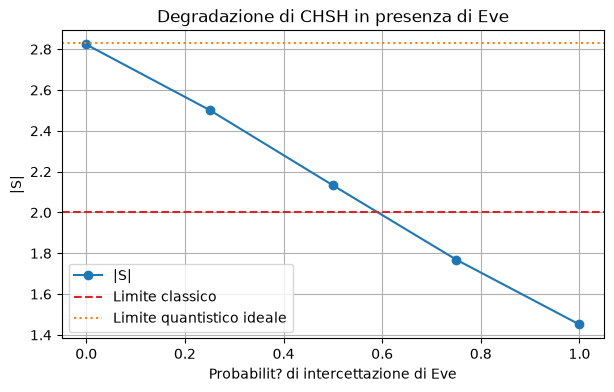

In [45]:
plt.figure(figsize=(7, 4))
plt.plot(
    chsh_df["intercept_probability"],
    chsh_df["abs_S"],
    marker="o",
    color="tab:blue",
    label="|S|",
)

plt.axhline(
    y=CHSH_CLASSICAL_LIMIT,
    color="tab:red",
    linestyle="--",
    label="Limite classico",
)

plt.axhline(
    y=CHSH_TSIRELSON_BOUND,
    color="tab:orange",
    linestyle=":",
    label="Limite quantistico ideale",
)

plt.xlabel("Probabilit? di intercettazione di Eve")
plt.ylabel("|S|")
plt.title("Degradazione di CHSH in presenza di Eve")
plt.grid(True)
plt.legend()
plt.show()


## Confronto tra QBER e CHSH

E91 permette di osservare due effetti dell?intercettazione:

- il QBER tende ad aumentare;
- |S| tende a diminuire.


In [46]:
e91_eve_comparison_df = qber_df.merge(
    chsh_df,
    on="intercept_probability",
    how="inner",
)

e91_eve_comparison_df


,intercept_probability,n_rounds,sifted_key_length,qber,shots,S,abs_S,violates_chsh,chsh_gap,chsh_strength,classical_limit,quantum_limit
0,0.00,1000,495,0.000000,2000,2.823,2.823,True,0.823,0.993449,2.0,2.828427
1,0.25,1000,492,0.058943,2000,2.502,2.502,True,0.502,0.605968,2.0,2.828427
2,0.50,1000,493,0.133874,2000,2.133,2.133,True,0.133,0.160545,2.0,2.828427
3,0.75,1000,538,0.211896,2000,1.769,1.769,False,-0.231,-0.278842,2.0,2.828427
4,1.00,1000,500,0.254000,2000,1.451,1.451,False,-0.549,-0.662702,2.0,2.828427


Nei casi in cui `violates_chsh` ? ancora True, Alice e Bob non possono concludere automaticamente che Eve sia assente. Devono guardare anche il valore quantitativo di |S| e il QBER.


In [47]:
qber_threshold = QBER_THRESHOLD_BB84

if "qber_key_rate_estimate" not in e91_eve_comparison_df.columns:
    e91_eve_comparison_df["qber_key_rate_estimate"] = None

for i in range(len(e91_eve_comparison_df)):
    qber = e91_eve_comparison_df.loc[i, "qber"]
    e91_eve_comparison_df.loc[i, "qber_key_rate_estimate"] = bb84_asymptotic_key_rate(qber)

e91_eve_comparison_df["accepted_by_qber"] = e91_eve_comparison_df["qber"] <= qber_threshold

# Decisione didattica semplificata: QBER accettabile e violazione CHSH formale.
e91_eve_comparison_df["accepted_final"] = (
    e91_eve_comparison_df["accepted_by_qber"]
    & e91_eve_comparison_df["violates_chsh"]
)

e91_eve_comparison_df


,intercept_probability,n_rounds,sifted_key_length,qber,shots,S,abs_S,violates_chsh,chsh_gap,chsh_strength,classical_limit,quantum_limit,qber_key_rate_estimate,accepted_by_qber,accepted_final
0,0.00,1000,495,0.000000,2000,2.823,2.823,True,0.823,0.993449,2.0,2.828427,1.0,True,True
1,0.25,1000,492,0.058943,2000,2.502,2.502,True,0.502,0.605968,2.0,2.828427,0.35353,True,True
2,0.50,1000,493,0.133874,2000,2.133,2.133,True,0.133,0.160545,2.0,2.828427,-0.135937,False,False
3,0.75,1000,538,0.211896,2000,1.769,1.769,False,-0.231,-0.278842,2.0,2.828427,-0.490182,False,False
4,1.00,1000,500,0.254000,2000,1.451,1.451,False,-0.549,-0.662702,2.0,2.828427,-0.635113,False,False


Questa decisione finale ? semplificata. Nel progetto, una chiave E91 viene considerata accettabile solo se:

- QBER <= soglia QBER didattica;
- |S| > 2, cio? se ? presente una violazione CHSH formale.

Questo criterio non prova automaticamente l'assenza di Eve. Per questo la tabella conserva anche `chsh_gap` e `chsh_strength`, che aiutano a valutare quanto la violazione sia vicina al limite classico oppure al limite quantistico ideale.


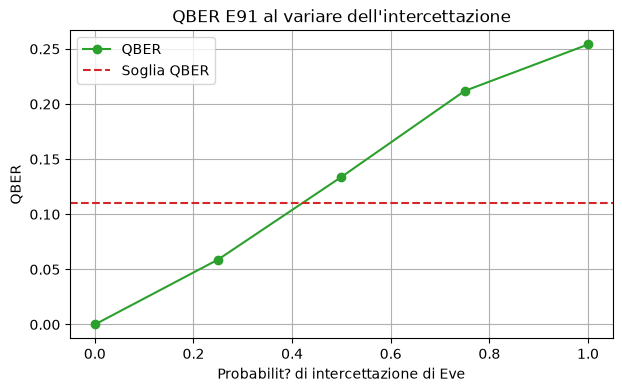

In [48]:
plt.figure(figsize=(7, 4))
plt.plot(
    e91_eve_comparison_df["intercept_probability"],
    e91_eve_comparison_df["qber"],
    marker="o",
    color="tab:green",
    label="QBER",
)
plt.axhline(
    y=QBER_THRESHOLD_BB84,
    color="tab:red",
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilit? di intercettazione di Eve")
plt.ylabel("QBER")
plt.title("QBER E91 al variare dell'intercettazione")
plt.grid(True)
plt.legend()
plt.show()


## Salvataggio risultati CHSH

Salviamo le nuove tabelle CHSH e confronto QBER/CHSH. Inoltre salviamo i grafici principali della sezione, mantenendo separata la simulazione dalla rappresentazione dei risultati.


In [49]:
chsh_table_path = tables_dir / "e91_eve_chsh_vs_interception.csv"
comparison_table_path = tables_dir / "e91_eve_qber_chsh_comparison.csv"

chsh_df.to_csv(chsh_table_path, index=False)
e91_eve_comparison_df.to_csv(comparison_table_path, index=False)

print(f"Tabella CHSH salvata in: {chsh_table_path}")
print(f"Tabella confronto QBER/CHSH salvata in: {comparison_table_path}")


Tabella CHSH salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_eve_chsh_vs_interception.csv
Tabella confronto QBER/CHSH salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_eve_qber_chsh_comparison.csv


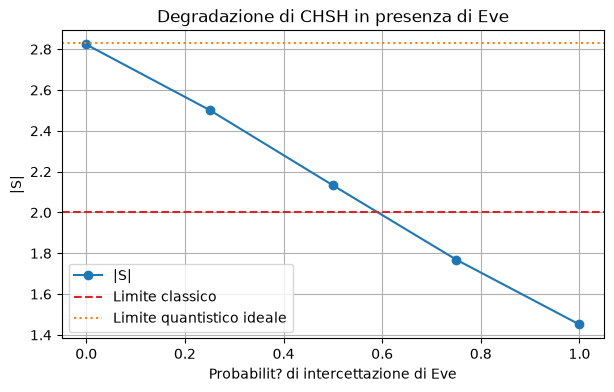

Grafico CHSH salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_eve_chsh_vs_interception.png


In [50]:
chsh_figure_path = figures_dir / "e91_eve_chsh_vs_interception.png"

plt.figure(figsize=(7, 4))
plt.plot(
    chsh_df["intercept_probability"],
    chsh_df["abs_S"],
    marker="o",
    color="tab:blue",
    label="|S|",
)
plt.axhline(
    y=CHSH_CLASSICAL_LIMIT,
    color="tab:red",
    linestyle="--",
    label="Limite classico",
)
plt.axhline(
    y=CHSH_TSIRELSON_BOUND,
    color="tab:orange",
    linestyle=":",
    label="Limite quantistico ideale",
)
plt.xlabel("Probabilit? di intercettazione di Eve")
plt.ylabel("|S|")
plt.title("Degradazione di CHSH in presenza di Eve")
plt.grid(True)
plt.legend()
plt.savefig(chsh_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico CHSH salvato in: {chsh_figure_path}")


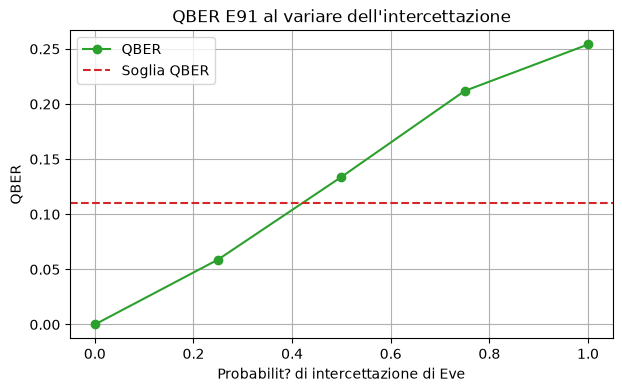

Grafico QBER salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_eve_qber_for_chsh_comparison.png


In [51]:
qber_chsh_figure_path = figures_dir / "e91_eve_qber_for_chsh_comparison.png"

plt.figure(figsize=(7, 4))
plt.plot(
    e91_eve_comparison_df["intercept_probability"],
    e91_eve_comparison_df["qber"],
    marker="o",
    color="tab:green",
    label="QBER",
)
plt.axhline(
    y=QBER_THRESHOLD_BB84,
    color="tab:red",
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilit? di intercettazione di Eve")
plt.ylabel("QBER")
plt.title("QBER E91 al variare dell'intercettazione")
plt.grid(True)
plt.legend()
plt.savefig(qber_chsh_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER salvato in: {qber_chsh_figure_path}")


Nel protocollo E91, l'intercettazione da parte di Eve ha due effetti osservabili:

- aumenta il QBER;
- riduce il parametro CHSH |S|.

Se Eve intercetta solo una frazione dei round, la violazione CHSH pu? rimanere formalmente presente, ma indebolita. Per questo non basta controllare il booleano `violates_chsh`: bisogna valutare anche `chsh_gap` e `chsh_strength`.

Questa analisi rende il confronto con BB84 pi? completo: BB84 usa principalmente il QBER come indicatore di disturbo, mentre E91 consente di usare sia QBER sia CHSH.


## E91 con sorgente classica non fidata

Finora abbiamo confrontato il protocollo E91 ideale con il caso in cui Eve intercetta e reinvia i qubit. In questa sezione consideriamo un altro scenario: una sorgente classica non fidata, che non prepara uno stato entangled ma invia coppie classicamente correlate, per esempio `|00>` oppure `|11>`.

Una sorgente di questo tipo pu? produrre correlazioni in alcune basi, ma non dovrebbe generare una violazione CHSH robusta. Il confronto tra QBER e CHSH aiuta quindi a distinguere le correlazioni classiche dalle correlazioni quantistiche dovute all'entanglement.


In [52]:
n_rounds_classical_source = 1000
seed_classical_source = 321

results_classical_source = run_e91_protocol_with_classical_source(
    n_rounds=n_rounds_classical_source,
    seed=seed_classical_source,
)

alice_key_classical_source, bob_key_classical_source = sift_keys(results_classical_source)
qber_classical_source = compute_qber(
    alice_key_classical_source,
    bob_key_classical_source,
)

print("Lunghezza chiave sifted con sorgente classica:", len(alice_key_classical_source))
print("QBER con sorgente classica:", qber_classical_source)


Lunghezza chiave sifted con sorgente classica: 512
QBER con sorgente classica: 0.212890625


Il QBER da solo non certifica sempre che la sorgente sia davvero quantistica. Una sorgente classica pu? generare bit correlati in alcune situazioni e quindi produrre un errore basso dopo il sifting. Per questo, nel protocollo E91, il test CHSH ? un controllo concettualmente importante.


In [53]:
classical_source_df = pd.DataFrame(results_classical_source)
classical_source_df.head()


,round,alice_basis,bob_basis,alice_bit,bob_bit,keep,source_type,source_bit
0,0,Z,Z,1,1,True,classical_correlated,1
1,1,X,Z,0,1,False,classical_correlated,1
2,2,Z,Z,0,0,True,classical_correlated,0
3,3,X,Z,1,0,False,classical_correlated,0
4,4,X,Z,1,0,False,classical_correlated,0


In [54]:
classical_source_summary = {
    "scenario": "E91 sorgente classica",
    "n_rounds": n_rounds_classical_source,
    "sifted_key_length": len(alice_key_classical_source),
    "qber": qber_classical_source,
}

classical_source_summary_df = pd.DataFrame([classical_source_summary])
classical_source_summary_df


,scenario,n_rounds,sifted_key_length,qber
0,E91 sorgente classica,1000,512,0.212891


## CHSH con sorgente classica

Se la sorgente invia coppie solo classicamente correlate, le correlazioni osservate non dovrebbero superare stabilmente il limite classico `|S| <= 2`. Questo rende CHSH uno strumento utile per distinguere una sorgente entangled ideale da una sorgente classica che imita alcune correlazioni.


In [55]:
shots_classical_chsh = 3000
seed_classical_chsh = 321

chsh_classical_source = run_chsh_experiment_with_classical_source(
    shots=shots_classical_chsh,
    seed=seed_classical_chsh,
)

chsh_classical_source


{'E_ab': 0.7193333333333334,
 'E_ab_prime': 0.7026666666666667,
 'E_a_prime_b': -0.013333333333333334,
 'E_a_prime_b_prime': 0.011333333333333334,
 'S': 1.3973333333333333,
 'shots': 3000,
 'source_type': 'classical_correlated',
 'abs_S': 1.3973333333333333,
 'classical_limit': 2.0,
 'quantum_limit': np.float64(2.8284271247461903),
 'violates_chsh': False,
 'chsh_gap': -0.6026666666666667,
 'chsh_strength': np.float64(-0.7274830201284258)}

In [56]:
source_chsh_comparison = [
    {
        "scenario": "E91 ideale",
        "abs_S": chsh_ideal["abs_S"],
        "violates_chsh": chsh_ideal["violates_chsh"],
        "chsh_gap": chsh_ideal["chsh_gap"],
        "chsh_strength": chsh_ideal["chsh_strength"],
    },
    {
        "scenario": "E91 con Eve intercept-resend",
        "abs_S": chsh_eve_full["abs_S"],
        "violates_chsh": chsh_eve_full["violates_chsh"],
        "chsh_gap": chsh_eve_full["chsh_gap"],
        "chsh_strength": chsh_eve_full["chsh_strength"],
    },
    {
        "scenario": "E91 sorgente classica",
        "abs_S": chsh_classical_source["abs_S"],
        "violates_chsh": chsh_classical_source["violates_chsh"],
        "chsh_gap": chsh_classical_source["chsh_gap"],
        "chsh_strength": chsh_classical_source["chsh_strength"],
    },
]

source_chsh_df = pd.DataFrame(source_chsh_comparison)
source_chsh_df


,scenario,abs_S,violates_chsh,chsh_gap,chsh_strength
0,E91 ideale,2.753000,True,0.753000,0.908951
1,E91 con Eve intercept-resend,1.437000,False,-0.563000,-0.679601
2,E91 sorgente classica,1.397333,False,-0.602667,-0.727483


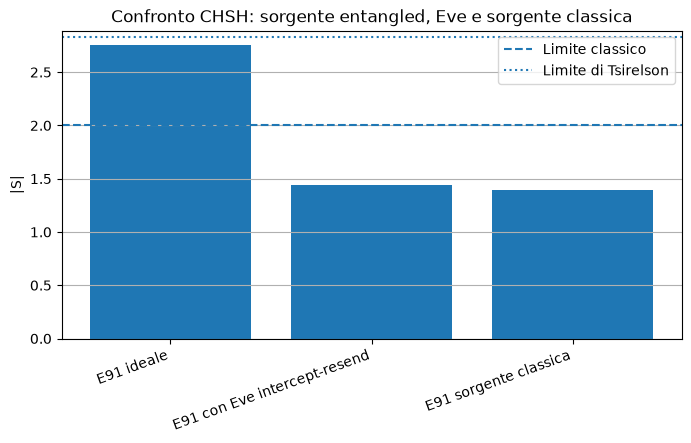

In [57]:
plt.figure(figsize=(8, 4))
plt.bar(
    source_chsh_df["scenario"],
    source_chsh_df["abs_S"],
)

plt.axhline(
    y=CHSH_CLASSICAL_LIMIT,
    linestyle="--",
    label="Limite classico"
)

plt.axhline(
    y=CHSH_TSIRELSON_BOUND,
    linestyle=":",
    label="Limite di Tsirelson"
)

plt.ylabel("|S|")
plt.title("Confronto CHSH: sorgente entangled, Eve e sorgente classica")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.legend()
plt.show()


## Salvataggio risultati sorgente classica

Salviamo ora la tabella riassuntiva dello scenario con sorgente classica e il confronto CHSH tra sorgente entangled, intercettazione di Eve e sorgente classica.


In [58]:
classical_summary_path = tables_dir / "e91_classical_source_summary.csv"
source_chsh_path = tables_dir / "e91_source_chsh_comparison.csv"

classical_source_summary_df.to_csv(classical_summary_path, index=False)
source_chsh_df.to_csv(source_chsh_path, index=False)

print(f"Tabella sorgente classica salvata in: {classical_summary_path}")
print(f"Confronto CHSH sorgenti salvato in: {source_chsh_path}")


Tabella sorgente classica salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_classical_source_summary.csv
Confronto CHSH sorgenti salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_source_chsh_comparison.csv


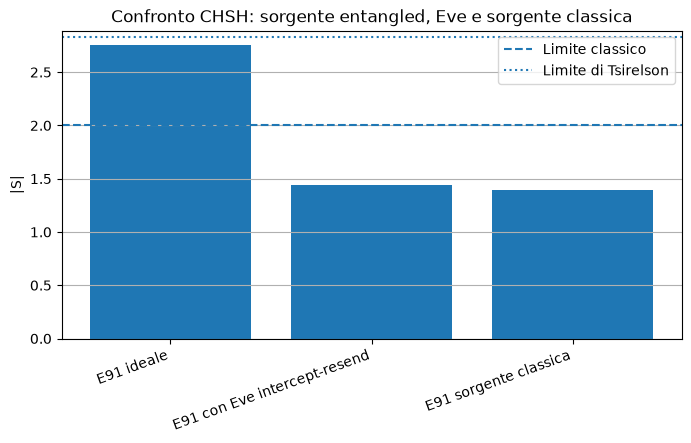

Grafico confronto CHSH sorgenti salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_source_chsh_comparison.png


In [59]:
figure_source_chsh_path = figures_dir / "e91_source_chsh_comparison.png"

plt.figure(figsize=(8, 4))
plt.bar(
    source_chsh_df["scenario"],
    source_chsh_df["abs_S"],
)

plt.axhline(
    y=CHSH_CLASSICAL_LIMIT,
    linestyle="--",
    label="Limite classico"
)

plt.axhline(
    y=CHSH_TSIRELSON_BOUND,
    linestyle=":",
    label="Limite di Tsirelson"
)

plt.ylabel("|S|")
plt.title("Confronto CHSH: sorgente entangled, Eve e sorgente classica")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.legend()
plt.savefig(figure_source_chsh_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico confronto CHSH sorgenti salvato in: {figure_source_chsh_path}")


Nel caso ideale, la sorgente entangled permette una violazione CHSH. L'intercettazione di Eve tende invece a degradare questa violazione, mentre una sorgente classica pu? produrre correlazioni ma non una violazione robusta del limite classico.

Questo confronto mostra perch? CHSH ? essenziale nell'interpretazione di E91: stati come `|00>` e `|11>` possono sembrare correlati in alcune basi, ma non riproducono le correlazioni quantistiche dello stato entangled.
